[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/zlatko-minev/pyEPR/master?filepath=_tutorial_notebooks%2FTutorial%206.%20EPR%20without%20HFSS%20%E2%80%94%20purely%20numerical%20workflow.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zlatko-minev/pyEPR/blob/master/_tutorial_notebooks/Tutorial%206.%20EPR%20without%20HFSS%20%E2%80%94%20purely%20numerical%20workflow.ipynb)

# Tutorial 6: EPR without HFSS — Purely Numerical Workflow

pyEPR's numerical diagonalization does **not** require Ansys HFSS. If you already
know (or can compute from another source) the three ingredients:

| Quantity | Symbol | Units | How to get it |
|---|---|---|---|
| Linearised mode frequencies | `freqs` | GHz | EM solver, circuit model, or experiment |
| Junction inductances at the bias point | `Ljs` | H | Circuit design / fabrication |
| Reduced zero-point flux fluctuations | `phi_zpf` | dimensionless | From EPR integrals or black-box quantisation |

you can call `epr_numerical_diagonalization` directly and obtain dressed frequencies
and the full dispersive-shift / anharmonicity matrix — no HFSS licence, no Ansys
installation, no COM calls.

This tutorial demonstrates the workflow for four common circuit types:

1. **Single transmon** — textbook single-junction qubit
2. **Transmon + readout resonator** — two-mode coupled system
3. **Fluxonium** — strongly anharmonic, requires `use_full_cos=True`
4. **Custom potential** — user-supplied V(φ) via `make_nonlinear_potential`

> **References**
> - Z. K. Minev *et al.*, *Energy-participation quantization of Josephson circuits*,
>   [npj Quantum Information **7**, 131 (2021)](https://doi.org/10.1038/s41534-021-00461-8)
>   ([arXiv:2010.00620](https://arxiv.org/abs/2010.00620)) — introduces pyEPR and the EPR framework.
> - S. E. Nigg *et al.*, *Black-box superconducting circuit quantization*,
>   [Phys. Rev. Lett. **108**, 240502 (2012)](https://doi.org/10.1103/PhysRevLett.108.240502)
>   — black-box quantisation (BBQ) that `black_box_hamiltonian` implements.
> - J. Koch *et al.*, *Charge-insensitive qubit design derived from the Cooper pair box*,
>   [Phys. Rev. A **76**, 042319 (2007)](https://doi.org/10.1103/PhysRevA.76.042319) — transmon.
> - V. E. Manucharyan *et al.*, *Fluxonium: Single Cooper-pair circuit free of charge offsets*,
>   [Science **326**, 113 (2009)](https://doi.org/10.1126/science.1177114) — fluxonium.
> - A. Petrescu, C. T. Hann, Z. K. Minev *et al.*, [arXiv:2411.15039](https://arxiv.org/abs/2411.15039)
>   — full-cosine EPR for very anharmonic circuits.


> **Series navigation:** [← Tutorial 5: Generic Junction Potential & Fluxonium](Tutorial%205.%20Generic%20junction%20potential%20and%20fluxonium%20EPR.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyEPR_pyaedt.calcs.back_box_numeric import (
    epr_numerical_diagonalization,
    make_nonlinear_potential,
)
from pyEPR_pyaedt.calcs.constants import hbar, fluxQ

# Useful physical constants
Phi0_over_2pi = fluxQ   # Φ₀/2π in Wb  (the reduced flux quantum)
print(f"Φ₀/2π = {fluxQ:.4e} Wb")

Φ₀/2π = 3.2911e-16 Wb


---

## Background: what are `freqs`, `Ljs`, `phi_zpf`?

### Linearised mode frequencies `freqs`

The EPR framework replaces each Josephson junction by its **linearised inductance**
$L_j = (\Phi_0/2\pi)^2 / E_J$ and finds the normal modes of the resulting linear circuit.
These are the frequencies that an EM solver (HFSS) or a lumped-circuit model would give
for the system with the junctions replaced by inductors.

For a transmon with $E_J/h = 20\,\text{GHz}$ and $E_C/h = 0.3\,\text{GHz}$, the
plasma frequency is $\omega_p/2\pi = \sqrt{8 E_J E_C}/h \approx 6.9\,\text{GHz}$.

### Junction inductance `Ljs`

$L_j = (\Phi_0/2\pi)^2 / E_J$. For $E_J/h = 20\,\text{GHz}$:
$$L_j = \frac{(\Phi_0/2\pi)^2}{h \times 20\,\text{GHz}} \approx 8.3\,\text{nH}$$

### Zero-point flux fluctuation `phi_zpf`

The reduced ZPF of mode $m$ across junction $j$ is
$$\varphi_{\rm zpf}^{(m,j)} = \sqrt{\frac{\hbar \omega_m}{2} \cdot \frac{L_j}{(\Phi_0/2\pi)^2}}
= \sqrt{\frac{E_m}{2 E_J}}$$

where $E_m = \hbar\omega_m$ is the zero-point energy of the mode. For a single-mode
transmon this is just $\phi_{\rm zpf} = (2 E_C/E_J)^{1/4}$ (the standard result).

The `phi_zpf` array has shape **(n_modes × n_junctions)**.

---

## 1 — Single transmon

### Setting up parameters from $E_J$ and $E_C$

A transmon has $E_J \gg E_C$. The plasma (linearised) frequency is
$\omega_p/2\pi = \sqrt{8 E_J E_C}/h$, and the single-mode ZPF is $(2 E_C / E_J)^{1/4}$.

In [2]:
h = 6.626e-34   # Planck constant

# Transmon energies (in GHz × h, converted to Joules)
EJ_GHz = 20.0   # Josephson energy
EC_GHz =  0.3   # charging energy

EJ = EJ_GHz * 1e9 * h   # Joules
EC = EC_GHz * 1e9 * h

# Linearised plasma frequency (GHz)
f_plasma = np.sqrt(8 * EJ * EC) / h / 1e9
print(f"Plasma frequency:  {f_plasma:.3f} GHz")

# Josephson inductance (H)
Lj = fluxQ**2 / EJ
print(f"Josephson inductance: {Lj*1e9:.2f} nH")

# Zero-point phase fluctuation (dimensionless)
phi_zpf_transmon = (2 * EC / EJ) ** 0.25
print(f"phi_zpf:  {phi_zpf_transmon:.4f}  (≪ 1, weakly anharmonic — truncated series works)")

Plasma frequency:  6.928 GHz
Josephson inductance: 8.17 nH
phi_zpf:  0.4162  (≪ 1, weakly anharmonic — truncated series works)


In [3]:
# Pack into arrays: shape = (n_modes,) and (n_modes × n_junctions)
freqs   = np.array([f_plasma])            # 1 mode, GHz
Ljs     = np.array([Lj])                  # 1 junction, H
phi_zpf = np.array([[phi_zpf_transmon]])  # shape (1 mode, 1 junction)

f_ND, chi_ND = epr_numerical_diagonalization(
    freqs, Ljs, phi_zpf, cos_trunc=8, fock_trunc=15
)

print(f"Dressed frequency:    {np.real(f_ND[0])/1e9:.4f} GHz")
print(f"Anharmonicity (χ/2π): {np.real(chi_ND[0,0]):.1f} MHz")

# Compare with analytic result: α ≈ -EC (in the transmon limit)
print(f"\nAnalytic anharmonicity ≈ EC/h = {EC_GHz*1e3:.0f} MHz  (pyEPR: {np.real(chi_ND[0,0]):.0f} MHz)")

INFO 03:41PM [make_dispersive]: Starting diagonalization (15×15 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


Dressed frequency:    6.6135 GHz
Anharmonicity (χ/2π): 336.9 MHz

Analytic anharmonicity ≈ EC/h = 300 MHz  (pyEPR: 337 MHz)


---

## 2 — Transmon coupled to a readout resonator

A two-mode system: the transmon mode (qubit) and a readout cavity. In this model the
junction participates in both modes via the participation ratios $\varphi_{\rm zpf}$.

* `freqs[0]` = qubit linearised frequency  
* `freqs[1]` = readout resonator frequency  
* `phi_zpf[0, 0]` = qubit ZPF across the junction (large)  
* `phi_zpf[1, 0]` = readout ZPF across the junction (small — dispersive coupling)

The off-diagonal `chi_ND[0,1]` gives the **dispersive shift** $\chi_{qr}$.

In [4]:
freqs_2mode   = np.array([5.5, 7.0])           # qubit, resonator (GHz)
Ljs_2mode     = np.array([Lj])                  # single junction (H)

# phi_zpf: shape (n_modes=2, n_junctions=1)
# Qubit mode has large ZPF; resonator mode has small ZPF across the junction
phi_zpf_2mode = np.array([[0.20],   # qubit participation
                           [0.02]])  # resonator participation

f2, chi2 = epr_numerical_diagonalization(
    freqs_2mode, Ljs_2mode, phi_zpf_2mode,
    cos_trunc=8, fock_trunc=10,
)

print("Dressed frequencies:")
print(f"  Qubit:    {np.real(f2[0])/1e9:.4f} GHz")
print(f"  Readout:  {np.real(f2[1])/1e9:.4f} GHz")
print()
print("χ matrix (MHz):")
chi2_r = np.real(chi2)
print(f"  χ_qq (qubit anharmonicity): {chi2_r[0,0]:.2f} MHz")
print(f"  χ_rr (readout self-Kerr):   {chi2_r[1,1]:.3f} MHz")
print(f"  χ_qr (dispersive shift):    {chi2_r[0,1]:.3f} MHz")

INFO 03:41PM [make_dispersive]: Starting diagonalization (100×100 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


Dressed frequencies:
  Qubit:    5.4839 GHz
  Readout:  6.9998 GHz

χ matrix (MHz):
  χ_qq (qubit anharmonicity): 15.89 MHz
  χ_rr (readout self-Kerr):   0.002 MHz
  χ_qr (dispersive shift):    0.308 MHz


---

## 3 — Fluxonium: exact cosine is essential

For a fluxonium-type circuit the zero-point phase fluctuation is large ($\varphi_{\rm zpf} \sim 1{-}3$).
The truncated Taylor series of $\cos\varphi - 1 + \varphi^2/2$ diverges in this regime;
set `use_full_cos=True` to use the matrix-exponential path instead.

See [arXiv:2411.15039](https://arxiv.org/abs/2411.15039) for a detailed comparison.

In [5]:
# Fluxonium parameters: large inductance → large phi_zpf
freqs_fl   = np.array([0.5])     # GHz  (plasmon mode, ~0.5–2 GHz typical)
Ljs_fl     = np.array([500e-9])  # H    (large superinductance Lj ≫ standard)
phi_zpf_fl = np.array([[2.0]])   # dimensionless (large!)

print("Fluxonium — comparing truncation levels:")
print()

results = {}
for trunc, label in [(4, 'cos_trunc=4'), (8, 'cos_trunc=8'), (16, 'cos_trunc=16')]:
    f, chi = epr_numerical_diagonalization(
        freqs_fl, Ljs_fl, phi_zpf_fl,
        cos_trunc=trunc, fock_trunc=25
    )
    results[label] = (np.real(f[0]), np.real(chi[0,0]))
    print(f"  {label:15s}:  f = {np.real(f[0])/1e9:.4f} GHz,  χ = {np.real(chi[0,0]):.2f} MHz")

f_exact, chi_exact = epr_numerical_diagonalization(
    freqs_fl, Ljs_fl, phi_zpf_fl,
    fock_trunc=25, use_full_cos=True    # ← recommended for fluxonium
)
print(f"  {'use_full_cos':15s}:  f = {np.real(f_exact[0])/1e9:.4f} GHz,  χ = {np.real(chi_exact[0,0]):.2f} MHz  ← exact")

print()
for label, (f_val, chi_val) in results.items():
    err = abs(f_val - np.real(f_exact[0])) / abs(np.real(f_exact[0]))
    print(f"  {label}: relative error vs. exact = {err:.1%}")

INFO 03:41PM [make_dispersive]: Starting diagonalization (25×25 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


INFO 03:41PM [make_dispersive]: Starting diagonalization (25×25 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


INFO 03:41PM [make_dispersive]: Starting diagonalization (25×25 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


INFO 03:41PM [make_dispersive]: Starting diagonalization (25×25 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


Fluxonium — comparing truncation levels:

  cos_trunc=4    :  f = 57729.3828 GHz,  χ = 57729380.03 MHz
  cos_trunc=8    :  f = 602249.4553 GHz,  χ = 602251647.74 MHz
  cos_trunc=16   :  f = 1474.8288 GHz,  χ = 1476793.06 MHz
  use_full_cos   :  f = 39.0206 GHz,  χ = 40984.63 MHz  ← exact

  cos_trunc=4: relative error vs. exact = 147846.0%
  cos_trunc=8: relative error vs. exact = 1543315.2%
  cos_trunc=16: relative error vs. exact = 3679.6%


### Fock-space convergence check

Always verify that the result is converged with respect to `fock_trunc`.

INFO 03:41PM [make_dispersive]: Starting diagonalization (10×10 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


INFO 03:41PM [make_dispersive]: Starting diagonalization (15×15 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


INFO 03:41PM [make_dispersive]: Starting diagonalization (20×20 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


INFO 03:41PM [make_dispersive]: Starting diagonalization (25×25 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


INFO 03:41PM [make_dispersive]: Starting diagonalization (30×30 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


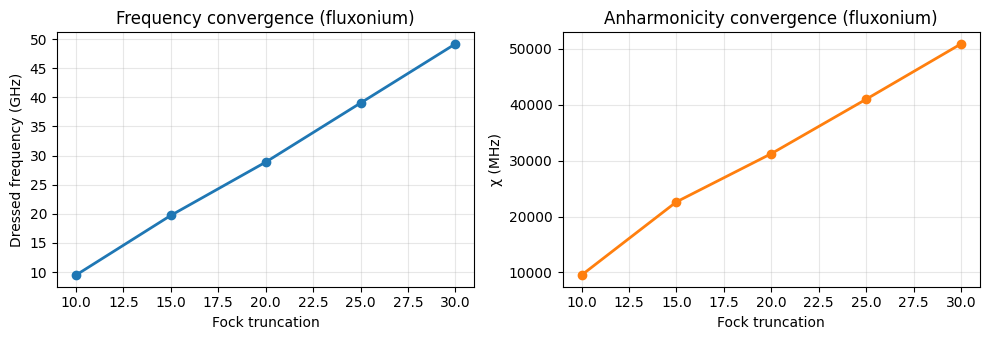

Converged values:  f = 49.1677 GHz,  χ = 50884.35 MHz


In [6]:
fock_range = [10, 15, 20, 25, 30]
f_vals  = []
chi_vals = []

for ft in fock_range:
    f, chi = epr_numerical_diagonalization(
        freqs_fl, Ljs_fl, phi_zpf_fl,
        fock_trunc=ft, use_full_cos=True
    )
    f_vals.append(np.real(f[0])/1e9)
    chi_vals.append(np.real(chi[0, 0]))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(fock_range, f_vals, 'o-', lw=2)
axes[0].set(xlabel='Fock truncation', ylabel='Dressed frequency (GHz)',
            title='Frequency convergence (fluxonium)')
axes[1].plot(fock_range, chi_vals, 'o-', lw=2, color='C1')
axes[1].set(xlabel='Fock truncation', ylabel='χ (MHz)',
            title='Anharmonicity convergence (fluxonium)')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Converged values:  f = {f_vals[-1]:.4f} GHz,  χ = {chi_vals[-1]:.2f} MHz")

---

## 4 — Custom potential via `make_nonlinear_potential`

If the junction element has a potential that is not a simple cosine — for example an
asymmetric SQUID, a flux-biased junction, or a non-standard Josephson element — you
can provide an arbitrary scalar function and let pyEPR construct the nonlinear
correction automatically.

See **Tutorial 5** for a detailed treatment. Here we show the minimal usage pattern.

In [7]:
# Asymmetric SQUID: effective potential for the common-mode phase
#   V(φ) = cos(φ)·cos(φ_ext) + d·sin(φ)·sin(φ_ext)
# where d = (Ej1 - Ej2)/(Ej1 + Ej2), φ_ext = external flux (reduced)

phi_ext = 0.3   # rad
d       = 0.1   # junction asymmetry

def V_squid(phi):
    return np.cos(phi) * np.cos(phi_ext) + d * np.sin(phi) * np.sin(phi_ext)

phi_min_squid = np.arctan(-d * np.tan(phi_ext)) % np.pi
print(f"Potential minimum at phi_min = {phi_min_squid:.4f} rad")

nl_squid = make_nonlinear_potential(V_squid, phi_min=phi_min_squid)

f_sq, chi_sq = epr_numerical_diagonalization(
    freqs, Ljs, phi_zpf,        # reuse single-transmon params from §1
    fock_trunc=15,
    non_linear_potential=nl_squid,
)

print(f"Asymmetric SQUID:  f = {np.real(f_sq[0])/1e9:.4f} GHz,  χ = {np.real(chi_sq[0,0]):.2f} MHz")

INFO 03:41PM [make_dispersive]: Starting diagonalization (15×15 matrix)


INFO 03:41PM [make_dispersive]: Diagonalization complete


Potential minimum at phi_min = 3.1107 rad
Asymmetric SQUID:  f = 7.2082 GHz,  χ = -234.67 MHz


---

## Interpreting the output

| Output | Meaning |
|---|---|
| `f_ND[m]` | Dressed frequency of mode *m* in GHz. Shift from linearised frequency reflects the Lamb shift from the junction nonlinearity. |
| `chi_ND[m, m]` | Self-anharmonicity of mode *m* in MHz. For a qubit, this is the anharmonicity α = ω₁₂ − ω₀₁. Positive = red-shifted (normal sign convention). |
| `chi_ND[m, n]` (m≠n) | Dispersive coupling between modes *m* and *n* in MHz. |

### Tips for reliable results

1. **Fock truncation**: always check convergence by running at two `fock_trunc` values. A rule of thumb: `fock_trunc ≥ 10 / phi_zpf` per junction.
2. **Cosine truncation**: for `phi_zpf ≲ 0.3` the default `cos_trunc=8` is accurate to < 0.1 %. For `phi_zpf ≳ 1`, always use `use_full_cos=True`.
3. **Units**: `freqs` must be in GHz, `Ljs` in Henries. The function asserts this and rejects values that look like they might be in the wrong units.
4. **Multi-junction**: `phi_zpf` is shape `(n_modes, n_junctions)` — each column is one junction, each row is one mode.

### Obtaining `phi_zpf` without HFSS

If you are using a lumped-circuit model, the ZPF can be derived analytically from the
energy participation of each mode in each junction inductance:

$$\varphi_{\rm zpf}^{(m,j)} = \sqrt{\frac{\hbar\omega_m}{2} \cdot \frac{L_j}{(\Phi_0/2\pi)^2}}
= \sqrt{\frac{p_{mj}}{2} \cdot \frac{\hbar\omega_m}{E_{J,j}}}$$

where $p_{mj}$ is the energy participation ratio of mode *m* in junction *j*.
For a simple transmon with a single LC mode: $p_{11} = 1$ and
$\varphi_{\rm zpf} = (2E_C/E_J)^{1/4}$ (the textbook result).